# COE 311 K Final Project Part 1
Rithika Bakshi

rb49258

### Section 1: Introduction & Model Selection

The system I chose is a damped mechanical system. It represents the motion of a mass attached to a spring and a damper (also called a dashpot). When the mass is displaced from its equilibrium position, the spring provides a restorative force, while the damper provides a resistive force proportional to the velocity, gradually dissipating energy from the system until the mass comes to a rest.

The governing second order ODE is $\frac{d^2y}{dt^2} + 2\zeta\omega\frac{dy}{dt} + \omega^2y = 0$

$\zeta$ is the damping ratio, which measures how quickly the oscillations decay

$\omega$ is the natural frequency, which is the frequency the system would oscillate at if there were no damping ($\zeta = 0$). It depends on the stiffness of the spring and the mass.

Let: $y_1 = y(t)$ and $y_2 = \frac{dy}{dt}$

Then: $\frac{dy_1}{dt} = y_2$ and $\frac{dy_2}{dt} = -2\zeta\omega y_2 - \omega^2y_1$

### Section 2: Parameter Research & Justification

This model represents the free vibration of a low E-string on an acoustic guitar. As the string vibrates, it loses energy through air resistance and and the transfer of vibrational energy through the bridge to the guitar’s soundboard. This loss of energy is modeled as damping, resulting in the decay of the note after a few seconds.



$\zeta = 0.0015$

Difficult to determine, I had to use Gemini, but cited the paper it used:

The Research: Experimental data shows that high-quality steel strings have a "Quality Factor" ($Q$) between 300 and 1000.The Relationship: In physics, the damping ratio is related to the $Q$ factor by $\zeta = \frac{1}{2Q}$.The Choice: I chose $\zeta = 0.0015$ because it represents a middle-ground for a steel string vibrating against a wooden bridge.

$\omega = 517.8$

A Low E-string is tuned to 82.41 Hz

$\omega = 2\pi f = 2 \times 3.14159 \times 82.41 = 517.8$


Initial displacement: 0.005 m (5mm) --> represents plucking the string

Initial velocity: 0 m/s --> string starts at rest

### Section 3: Numerical Methods Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt

def euler_guitar(step_size):
    # Define the parameters --> updated for guitar string
    omega = 517.8 # Natural frequency
    zeta = 0.0015 # Damping ratio
    h = step_size # Step size controlled by function argument
    x_start = 0 # Start of the interval
    x_end = 0.05 # End of the interval
    y_0 = 0.005 # Initial condition for y (5mm pluck)
    v_0 = 0.0 # Initial condition for dy/dx

    # Create arrays to store x, y, and v values
    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))
    v_values = np.zeros(len(x_values))

    # Set initial conditions
    y_values[0] = y_0
    v_values[0] = v_0

    # Euler's Method loop
    for i in range(1, len(x_values)):
        # Current values
        x_n = x_values[i - 1]
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]
        
        # Update equations
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-2 * zeta * omega * v_n - (omega**2) * y_n)
        
    return x_values, y_values, v_values



def rk4_guitar(step_size):
    # Parameters stay exactly the same
    omega = 517.8
    zeta = 0.0015
    h = step_size
    x_start = 0
    x_end = 0.05 # Shorter window to see the sine wave clearly
    y_0 = 0.005
    v_0 = 0.0

    # Create arrays
    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))
    v_values = np.zeros(len(x_values))

    # Initial conditions
    y_values[0] = y_0
    v_values[0] = v_0

    
    def f(y, v):
        dydt = v
        dvdt = -2 * zeta * omega * v - (omega**2) * y
        return dydt, dvdt

    # RK4 iteration
    for i in range(1, len(x_values)):
        y_n = y_values[i-1]
        v_n = v_values[i-1]

        # Calculate the 4 slopes (k values)
        k1y, k1v = f(y_n, v_n)
        
        k2y, k2v = f(y_n + 0.5 * h * k1y, v_n + 0.5 * h * k1v)
        
        k3y, k3v = f(y_n + 0.5 * h * k2y, v_n + 0.5 * h * k2v)
        
        k4y, k4v = f(y_n + h * k3y, v_n + h * k3v)

        # Update position and velocity
        y_values[i] = y_n + (h / 6.0) * (k1y + 2*k2y + 2*k3y + k4y)
        v_values[i] = v_n + (h / 6.0) * (k1v + 2*k2v + 2*k3v + k4v)

    return x_values, y_values, v_values

explanation of implementation approach

### Section 4: Solutions & Comparison

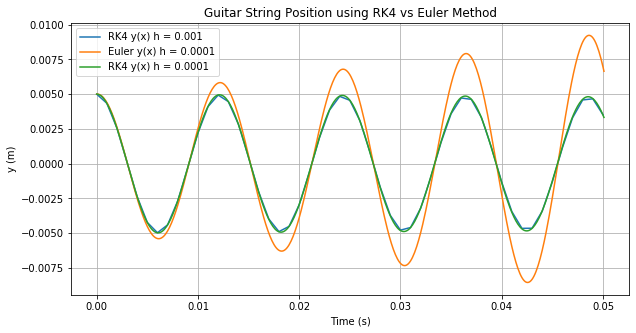

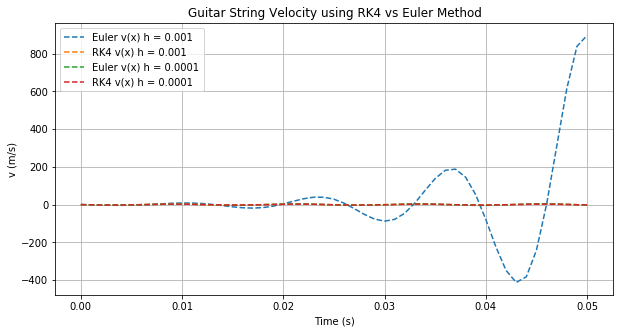

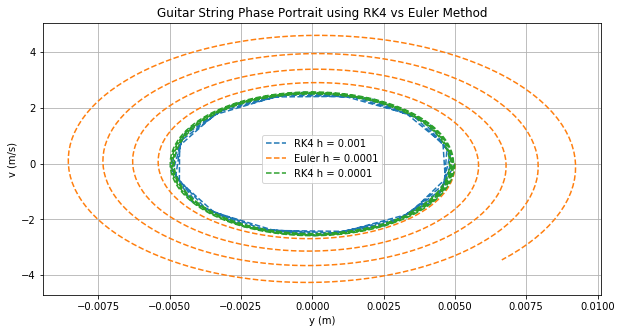

In [2]:
plt.figure(figsize=(10, 5))

x_values, y_values, v_values = euler_guitar(0.001)
# plt.plot(x_values, y_values, label='Euler y(x) h = 0.001')

x_values, y_values, v_values = rk4_guitar(0.001)
plt.plot(x_values, y_values, label='RK4 y(x) h = 0.001')

x_values, y_values, v_values = euler_guitar(0.0001)
plt.plot(x_values, y_values, label='Euler y(x) h = 0.0001')

x_values, y_values, v_values = rk4_guitar(0.0001)
plt.plot(x_values, y_values, label='RK4 y(x) h = 0.0001')

plt.xlabel('Time (s)')
plt.ylabel('y (m)')
plt.title('Guitar String Position using RK4 vs Euler Method')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))

x_values, y_values, v_values = euler_guitar(0.001)
plt.plot(x_values, v_values, label='Euler v(x) h = 0.001', linestyle='--')

x_values, y_values, v_values = rk4_guitar(0.001)
plt.plot(x_values, v_values, label='RK4 v(x) h = 0.001', linestyle='--')

x_values, y_values, v_values = euler_guitar(0.0001)
plt.plot(x_values, v_values, label='Euler v(x) h = 0.0001', linestyle='--')

x_values, y_values, v_values = rk4_guitar(0.0001)
plt.plot(x_values, v_values, label='RK4 v(x) h = 0.0001', linestyle='--')


plt.xlabel('Time (s)')
plt.ylabel('v (m/s)')
plt.title('Guitar String Velocity using RK4 vs Euler Method')
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 5))

x_values, y_values, v_values = euler_guitar(0.001)
# plt.plot(y_values, v_values, label='Euler v(x) h = 0.001', linestyle='--')

x_values, y_values, v_values = rk4_guitar(0.001)
plt.plot(y_values, v_values, label='RK4 h = 0.001', linestyle='--')

x_values, y_values, v_values = euler_guitar(0.0001)
plt.plot(y_values, v_values, label='Euler h = 0.0001', linestyle='--')

x_values, y_values, v_values = rk4_guitar(0.0001)
plt.plot(y_values, v_values, label='RK4 h = 0.0001', linestyle='--')


plt.xlabel('y (m)')
plt.ylabel('v (m/s)')
plt.title('Guitar String Phase Portrait using RK4 vs Euler Method')
plt.legend()
plt.grid(True)
plt.show()

discussion of visual differences between methods

### Section 5: Stability Analysis

In [3]:
# stability analysis for euler's
def euler_guitar(step_size):
    # Define the parameters --> updated for guitar string
    omega = 517.8 # Natural frequency
    zeta = 0.0015 # Damping ratio
    h = step_size # Step size controlled by function argument
    x_start = 0 # Start of the interval
    x_end = 0.05 # End of the interval
    y_0 = 0.005 # Initial condition for y (5mm pluck)
    v_0 = 0.0 # Initial condition for dy/dx
    
    # NEW - evaluate stability using eigenvalues
    A = [[1, h],[-1*h*omega**2, 1-2*h*zeta*omega]]
    evals = np.linalg.eigvals(A)
    print(evals)
    count = 0
    for i in evals:
        if(abs(i)>0):
            count=count+1
    if(count>0):
        print("Solution may not be Entirely Stable\n")
    else:
        print("Solution is Stable\n")

    # Create arrays to store x, y, and v values
    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))
    v_values = np.zeros(len(x_values))

    # Set initial conditions
    y_values[0] = y_0
    v_values[0] = v_0

    # Euler's Method loop
    for i in range(1, len(x_values)):
        # Current values
        x_n = x_values[i - 1]
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]
        
        # Update equations
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-2 * zeta * omega * v_n - (omega**2) * y_n)
        
    return x_values, y_values, v_values

print("Euler's Method, step size = 0.001")
x_values, y_values, v_values = euler_guitar(0.001)

print("Euler's Method, step size = 0.0001")
x_values, y_values, v_values = euler_guitar(0.0001)

# stability for RK4
def rk4_guitar(step_size):
    # Parameters stay exactly the same
    omega = 517.8
    zeta = 0.0015
    h = step_size
    x_start = 0
    x_end = 0.05 # Shorter window to see the sine wave clearly
    y_0 = 0.005
    v_0 = 0.0
    
    sys_A = np.array([[0, 1], [-(omega**2), -2*zeta*omega]])
    
    # 2. Get eigenvalues of the physical system (λ)
    sys_evals = np.linalg.eigvals(sys_A)
    
    # 3. Calculate growth factors using the RK4 stability function:
    # R(z) = 1 + z + z^2/2 + z^3/6 + z^4/24, where z = h*λ
    rk4_growth_factors = []
    for lam in sys_evals:
        z = h * lam
        R_z = 1 + z + (z**2)/2 + (z**3)/6 + (z**4)/24
        rk4_growth_factors.append(abs(R_z))
    
    print(f"RK4 Growth Factors: {rk4_growth_factors}")
    
    # Check if any growth factor is > 1
    unstable_count = sum(1 for factor in rk4_growth_factors if factor > 1.0)
    
    if unstable_count > 0:
        print("Solution may not be Entirely Stable\n")
    else:
        print("Solution is Stable\n")

    # Create arrays
    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))
    v_values = np.zeros(len(x_values))

    # Initial conditions
    y_values[0] = y_0
    v_values[0] = v_0

    
    def f(y, v):
        dydt = v
        dvdt = -2 * zeta * omega * v - (omega**2) * y
        return dydt, dvdt

    # RK4 iteration
    for i in range(1, len(x_values)):
        y_n = y_values[i-1]
        v_n = v_values[i-1]

        # Calculate the 4 slopes (k values)
        k1y, k1v = f(y_n, v_n)
        
        k2y, k2v = f(y_n + 0.5 * h * k1y, v_n + 0.5 * h * k1v)
        
        k3y, k3v = f(y_n + 0.5 * h * k2y, v_n + 0.5 * h * k2v)
        
        k4y, k4v = f(y_n + h * k3y, v_n + h * k3v)

        # Update position and velocity
        y_values[i] = y_n + (h / 6.0) * (k1y + 2*k2y + 2*k3y + k4y)
        v_values[i] = v_n + (h / 6.0) * (k1v + 2*k2v + 2*k3v + k4v)

    return x_values, y_values, v_values

print("RK4 Method, step size = 0.001")
x_values, y_values, v_values = rk4_guitar(0.001)

print("RK4 Method, step size = 0.0001")
x_values, y_values, v_values = rk4_guitar(0.0001)

Euler's Method, step size = 0.001
[0.9992233+0.51779942j 0.9992233-0.51779942j]
Solution may not be Entirely Stable

Euler's Method, step size = 0.0001
[0.99992233+0.05177994j 0.99992233-0.05177994j]
Solution may not be Entirely Stable

RK4 Method, step size = 0.001
RK4 Growth Factors: [0.9990963574127032, 0.9990963574127032]
Solution is Stable

RK4 Method, step size = 0.0001
RK4 Growth Factors: [0.9999223329056808, 0.9999223329056808]
Solution is Stable



RK4 Growth Factors: [0.9999223329056808, 0.9999223329056808]
Solution is Stable

[0.99992233+0.05177994j 0.99992233-0.05177994j]
Solution may not be Entirely Stable

RK4 Growth Factors: [0.9990963574127032, 0.9990963574127032]
Solution is Stable

[0.9992233+0.51779942j 0.9992233-0.51779942j]
Solution may not be Entirely Stable



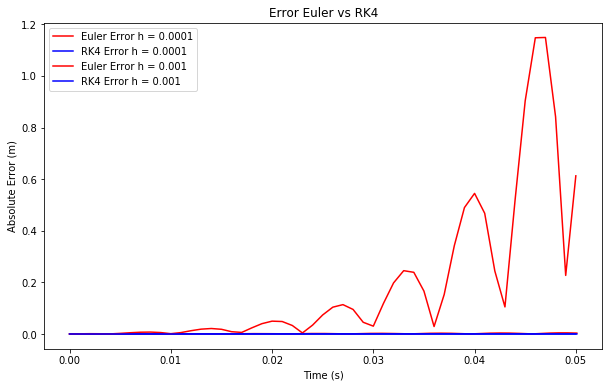

In [5]:
t, y_rk, v_rk = rk4_guitar(0.0001)
t_eu, y_eu, v_eu = euler_guitar(0.0001)

# had to use Gemini for finding exact solution, diff eq is not my strongest subject :(
omega = 517.8
zeta = 0.0015
y0 = 0.005
wd = omega * np.sqrt(1 - zeta**2)

# Calculate exact values at every time 't'
y_exact = y0 * np.exp(-zeta * omega * t) * np.cos(wd * t)


error_rk4 = np.abs(y_rk - y_exact)
error_euler = np.abs(y_eu - y_exact)


plt.figure(figsize=(10, 6))
plt.plot(t, error_euler, label=f'Euler Error h = 0.0001', color='red')
plt.plot(t, error_rk4, label=f'RK4 Error h = 0.0001', color='blue')

t_rk, y_rk, v_rk = rk4_guitar(0.001)
t_eu, y_eu, v_eu = euler_guitar(0.001)

# had to use Gemini for finding exact solution, diff eq is not my strongest subject :(
omega = 517.8
zeta = 0.0015
y0 = 0.005
wd = omega * np.sqrt(1 - zeta**2)

# Calculate exact values at every time 't'
y_exact = y0 * np.exp(-zeta * omega * t_rk) * np.cos(wd * t_rk)


error_rk4 = np.abs(y_rk - y_exact)

y_exact = y0 * np.exp(-zeta * omega * t_eu) * np.cos(wd * t_eu)

error_euler = np.abs(y_eu - y_exact)

plt.plot(t_eu, error_euler, label=f'Euler Error h = 0.001', color='red')
plt.plot(t_rk, error_rk4, label=f'RK4 Error h = 0.001', color='blue')

plt.xlabel('Time (s)')
plt.ylabel('Absolute Error (m)')
plt.title('Error Euler vs RK4')

plt.legend()
plt.show()


### Sources
https://acta-acustica.edpsciences.org/articles/aacus/full_html/2020/03/aacus200019/aacus200019.html#:~:text=2.2%20Identification%20of%20damping&text=%E2%89%88%200.01%25%20is%20found%20around,12%2C%2013%2C%2026%5D.&text=Identified%20damping%20ratios%20over%20frequency,and%20fitted%20Rayleigh%20damping%20curve.&text=s.,are%20discussed%20in%20Section%205.


